# Step 6: LightGBM (Ensemble Model)

This notebook trains, evaluates, and interprets the **LightGBM gradient boosting model**
for predicting whether a user will reorder a given product in their next order.

## Prerequisites
- Steps 1–3 notebook must have been run first
- Step 4 (Logistic Regression) must have been run first — results are loaded for comparison
- Virtual environment must be active with dependencies installed

## Inputs (from Steps 1–3)

| File | Contents |
|---|---|
| `X_train.parquet` | Imputed (unscaled) training features — 29 cols |
| `X_test.parquet` | Imputed (unscaled) test features |
| `y_train.parquet` | Training labels |
| `y_test.parquet` | Test labels |
| `feature_cols.pkl` | Canonical feature list |

> **Note:** LightGBM does not require feature scaling. The raw imputed features
> are used directly. `aisle_id` and `department_id` are passed as native
> categoricals so LightGBM treats them as unordered groups rather than numbers.

## Inputs (from Step 4)

| File | Contents |
|---|---|
| `lr_results.csv` | Logistic Regression metrics — used as benchmark throughout |

## Roadmap
1. Load artefacts
2. Prepare categorical features
3. Train baseline LightGBM
4. Tune hyperparameters via cross-validated grid search
5. Evaluate — threshold-independent and threshold-dependent metrics
6. Feature importance
7. Compare with Logistic Regression baseline
8. Save model and results


## 0. Imports & Configuration

In [1]:
import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, brier_score_loss,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.6f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

RANDOM_STATE = 42

# ── Paths ─────────────────────────────────────────────────────────────────────
ARTEFACT_DIR = "../prepared_data"
MODEL_DIR    = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"ARTEFACT_DIR : {os.path.abspath(ARTEFACT_DIR)}")
print(f"MODEL_DIR    : {os.path.abspath(MODEL_DIR)}")
print(f"LightGBM version : {lgb.__version__}")


ARTEFACT_DIR : /Users/martinmilon/Documents/DTSC870/prepared_data
MODEL_DIR    : /Users/martinmilon/Documents/DTSC870/models
LightGBM version : 4.6.0


## 1. Load Artefacts

In [2]:
# ── features and labels ──────────────────────────────────────────────────────
X_train = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_train.parquet'))
X_test  = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_test.parquet'))
y_train = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'y_train.parquet'))['reordered']
y_test  = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'y_test.parquet'))['reordered']
FEATURE_COLS = joblib.load(os.path.join(ARTEFACT_DIR, 'feature_cols.pkl'))

print(f"X_train      : {X_train.shape}")
print(f"X_test       : {X_test.shape}")
print(f"y_train      : {y_train.shape}  |  positive rate: {y_train.mean()*100:.1f}%")
print(f"y_test       : {y_test.shape}   |  positive rate: {y_test.mean()*100:.1f}%")
print(f"Features     : {len(FEATURE_COLS)}")
print(f"NaNs X_train : {X_train.isnull().sum().sum()}")
print(f"NaNs X_test  : {X_test.isnull().sum().sum()}")

# ── Logistic Regression benchmark from Step 4 ─────────────────────────────────
lr_results = pd.read_csv(os.path.join(MODEL_DIR, 'lr_results.csv'))
print(f"\nLogistic Regression benchmark (Step 4):")
print(f"  ROC-AUC  : {lr_results['ROC-AUC'].values[0]:.4f}")
print(f"  PR-AUC   : {lr_results['PR-AUC (Avg Prec)'].values[0]:.4f}")
print(f"  Brier    : {lr_results['Brier Score'].values[0]:.4f}")
print(f"  F1       : {lr_results['F1 (optimal thresh)'].values[0]:.4f}")


X_train      : (1107416, 29)
X_test       : (277201, 29)
y_train      : (1107416,)  |  positive rate: 59.9%
y_test       : (277201,)   |  positive rate: 59.9%
Features     : 29
NaNs X_train : 0
NaNs X_test  : 0

Logistic Regression benchmark (Step 4):
  ROC-AUC  : 0.9689
  PR-AUC   : 0.9841
  Brier    : 0.0472
  F1       : 0.9520


## 2. Prepare Categorical Features

`aisle_id` and `department_id` are cast to pandas `category` dtype so LightGBM
treats them as unordered categoricals rather than continuous integers.
This is the key advantage over Logistic Regression for these two features —
LightGBM can find non-linear groupings within aisle/department without imposing
any ordinal assumption.


In [3]:
CAT_FEATURES = ['aisle_id', 'department_id']

X_tr = X_train[FEATURE_COLS].copy()
X_te = X_test[FEATURE_COLS].copy()

for col in CAT_FEATURES:
    X_tr[col] = X_tr[col].astype('category')
    X_te[col] = X_te[col].astype('category')

print("Categorical features set:")
for col in CAT_FEATURES:
    n = X_tr[col].nunique()
    print(f"  {col:<15} {n} unique values")

print(f"\nFeature dtypes summary:")
print(X_tr.dtypes.value_counts().to_string())


Categorical features set:
  aisle_id        134 unique values
  department_id   21 unique values

Feature dtypes summary:
float64     27
category     1
category     1


## 3. Class Imbalance — `scale_pos_weight`

LightGBM handles class imbalance via `scale_pos_weight`, which upweights the
minority class (not-reordered = 0) in the loss function.
The value is computed as n_negative / n_positive from the training set.


In [4]:
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / n_pos

print(f"Train positives      : {n_pos:,}")
print(f"Train negatives      : {n_neg:,}")
print(f"scale_pos_weight     : {scale_pos_weight:.4f}")


Train positives      : 662,892
Train negatives      : 444,524
scale_pos_weight     : 0.6706


## 4. Baseline LightGBM

We start with sensible defaults to establish a pre-tuning benchmark,
then tune in Section 5.

**Key parameter choices:**
- `objective='binary'` — binary classification
- `metric='auc'` — evaluated on ROC-AUC during training
- `scale_pos_weight` — class imbalance correction
- `n_estimators=500` with `early_stopping_rounds=50` — stops when validation AUC
  stops improving, preventing overfitting without needing to pre-specify tree count
- `categorical_feature='auto'` — LightGBM detects category dtype columns automatically


In [5]:
# split a small validation set from training data for early stopping
from sklearn.model_selection import train_test_split as tts

X_tr_fit, X_val, y_tr_fit, y_val = tts(
    X_tr, y_train, test_size=0.10, random_state=RANDOM_STATE, stratify=y_train)

lgb_baseline = lgb.LGBMClassifier(
    objective         = 'binary',
    metric            = 'auc',
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 63,
    min_child_samples = 50,
    scale_pos_weight  = scale_pos_weight,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbose           = -1
)

lgb_baseline.fit(
    X_tr_fit, y_tr_fit,
    eval_set          = [(X_val, y_val)],
    callbacks         = [lgb.early_stopping(stopping_rounds=50, verbose=False),
                         lgb.log_evaluation(period=-1)]
)

y_prob_baseline = lgb_baseline.predict_proba(X_te)[:, 1]
auc_baseline    = roc_auc_score(y_test, y_prob_baseline)

print(f"Baseline LightGBM trained.")
print(f"  Best iteration : {lgb_baseline.best_iteration_}")
print(f"  Test ROC-AUC   : {auc_baseline:.4f}  "
      f"(vs LR baseline: {lr_results['ROC-AUC'].values[0]:.4f})")


Baseline LightGBM trained.
  Best iteration : 489
  Test ROC-AUC   : 0.9711  (vs LR baseline: 0.9689)


## 5. Hyperparameter Tuning via Grid Search

We tune four of the most impactful LightGBM parameters:

| Parameter | Controls |
|---|---|
| `num_leaves` | Tree complexity — more leaves = more capacity but higher overfitting risk |
| `min_child_samples` | Minimum samples per leaf — regularises small splits |
| `learning_rate` | Step size — lower = more trees needed but often better generalisation |
| `max_depth` | Maximum tree depth — caps complexity independently of num_leaves |

`n_estimators` is handled by early stopping rather than grid search.


In [6]:
param_grid = {
    'num_leaves'        : [31, 63, 127],
    'min_child_samples' : [20, 50, 100],
    'learning_rate'     : [0.05, 0.1],
    'max_depth'         : [-1, 10],
}

lgb_cv = lgb.LGBMClassifier(
    objective        = 'binary',
    metric           = 'auc',
    n_estimators     = 300,
    scale_pos_weight = scale_pos_weight,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    verbose          = -1
)

grid_search = GridSearchCV(
    lgb_cv,
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

grid_search.fit(X_tr, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV AUC     : {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters : {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'num_leaves': 127}
Best CV AUC     : 0.9725


## 6. Tuned Model — Predicted Probabilities

In [7]:
lgb_tuned = grid_search.best_estimator_

y_prob_test  = lgb_tuned.predict_proba(X_te)[:, 1]
y_prob_train = lgb_tuned.predict_proba(X_tr)[:, 1]

print("Tuned model ready. Predicted probabilities computed.")
print(f"  Test prob range : [{y_prob_test.min():.4f}, {y_prob_test.max():.4f}]")
print(f"  Test prob mean  : {y_prob_test.mean():.4f}")


Tuned model ready. Predicted probabilities computed.
  Test prob range : [0.0024, 1.0000]
  Test prob mean  : 0.5833


## 7. Evaluation

### 7.1 Threshold-Independent Metrics


In [8]:
roc_auc  = roc_auc_score(y_test, y_prob_test)
avg_prec = average_precision_score(y_test, y_prob_test)
brier    = brier_score_loss(y_test, y_prob_test)

lr_auc   = lr_results['ROC-AUC'].values[0]
lr_prec  = lr_results['PR-AUC (Avg Prec)'].values[0]
lr_brier = lr_results['Brier Score'].values[0]

print("Threshold-Independent Metrics (Test Set)")
print(f"{'Metric':<30} {'LightGBM':>12} {'Logistic Reg':>14} {'Delta':>10}")
print("-" * 68)
print(f"{'ROC-AUC':<30} {roc_auc:>12.4f} {lr_auc:>14.4f} {roc_auc - lr_auc:>+10.4f}")
print(f"{'PR-AUC (Avg Precision)':<30} {avg_prec:>12.4f} {lr_prec:>14.4f} {avg_prec - lr_prec:>+10.4f}")
print(f"{'Brier Score (lower=better)':<30} {brier:>12.4f} {lr_brier:>14.4f} {brier - lr_brier:>+10.4f}")


Threshold-Independent Metrics (Test Set)
Metric                             LightGBM   Logistic Reg      Delta
--------------------------------------------------------------------
ROC-AUC                              0.9710         0.9689    +0.0021
PR-AUC (Avg Precision)               0.9851         0.9841    +0.0010
Brier Score (lower=better)           0.0458         0.0472    -0.0014


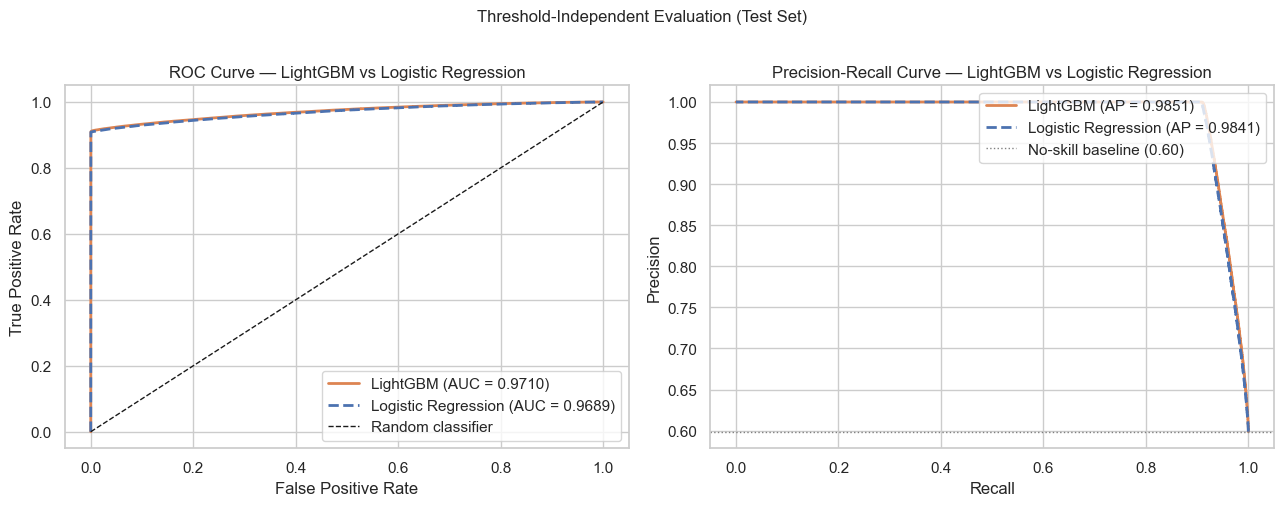

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_test)
lr_model = joblib.load(os.path.join(MODEL_DIR, 'lr_tuned.pkl'))
lr_coef  = joblib.load(os.path.join(MODEL_DIR, 'lr_coef_df.pkl'))

# load LR probs for overlay — regenerate from saved model
X_test_scaled = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_test_scaled.parquet'))
FEATURE_COLS_LR = [c for c in FEATURE_COLS if c != 'aisle_id']
y_prob_lr = lr_model.predict_proba(X_test_scaled[FEATURE_COLS_LR])[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
lr_auc_curve = roc_auc_score(y_test, y_prob_lr)

axes[0].plot(fpr_lgb, tpr_lgb, color='#DD8452', lw=2,
             label=f'LightGBM (AUC = {roc_auc:.4f})')
axes[0].plot(fpr_lr,  tpr_lr,  color='#4C72B0', lw=2, linestyle='--',
             label=f'Logistic Regression (AUC = {lr_auc_curve:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — LightGBM vs Logistic Regression')
axes[0].legend(loc='lower right')

# ── PR Curve ──────────────────────────────────────────────────────────────────
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_prob_test)
precision_lr,  recall_lr,  _ = precision_recall_curve(y_test, y_prob_lr)
baseline_prec = y_test.mean()

axes[1].plot(recall_lgb, precision_lgb, color='#DD8452', lw=2,
             label=f'LightGBM (AP = {avg_prec:.4f})')
axes[1].plot(recall_lr,  precision_lr,  color='#4C72B0', lw=2, linestyle='--',
             label=f'Logistic Regression (AP = {lr_prec:.4f})')
axes[1].axhline(baseline_prec, linestyle=':', color='grey', lw=1,
                label=f'No-skill baseline ({baseline_prec:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — LightGBM vs Logistic Regression')
axes[1].legend(loc='upper right')

plt.suptitle('Threshold-Independent Evaluation (Test Set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 7.2 Optimal Classification Threshold

Same F1-maximisation approach as Step 4, applied to LightGBM probabilities.


Optimal threshold (max F1) : 0.3899
F1 at optimal threshold    : 0.9533


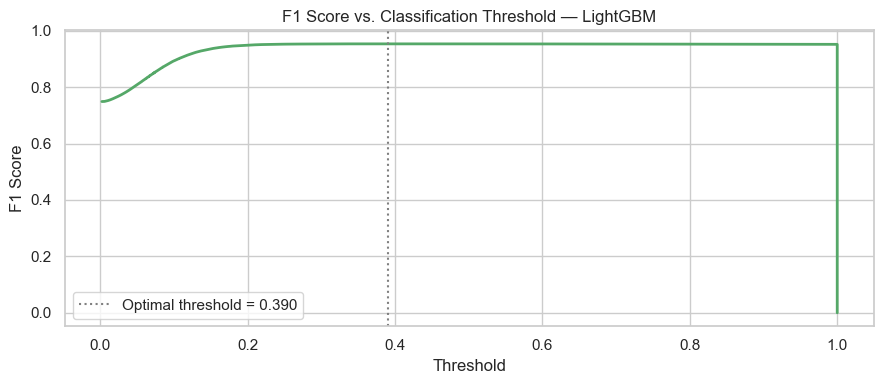

In [10]:
precision_t, recall_t, pr_thresholds = precision_recall_curve(y_test, y_prob_test)
f1_scores      = (2 * precision_t[:-1] * recall_t[:-1] /
                  (precision_t[:-1] + recall_t[:-1] + 1e-9))
best_idx       = np.argmax(f1_scores)
best_threshold = pr_thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal threshold (max F1) : {best_threshold:.4f}")
print(f"F1 at optimal threshold    : {best_f1:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(pr_thresholds, f1_scores, color='#55A868', lw=2)
plt.axvline(best_threshold, linestyle=':', color='grey',
            label=f'Optimal threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Classification Threshold — LightGBM')
plt.legend()
plt.tight_layout()
plt.show()


### 7.3 Threshold-Dependent Metrics

In [11]:
y_pred_05  = (y_prob_test >= 0.50).astype(int)
y_pred_opt = (y_prob_test >= best_threshold).astype(int)

print("Classification Report - Default Threshold (0.50)")
print(classification_report(y_test, y_pred_05,
                             target_names=['Not Reordered', 'Reordered']))

print(f"Classification Report - Optimal Threshold ({best_threshold:.3f})")
print(classification_report(y_test, y_pred_opt,
                             target_names=['Not Reordered', 'Reordered']))


Classification Report - Default Threshold (0.50)
               precision    recall  f1-score   support

Not Reordered       0.88      1.00      0.94    111269
    Reordered       1.00      0.91      0.95    165932

     accuracy                           0.95    277201
    macro avg       0.94      0.95      0.95    277201
 weighted avg       0.95      0.95      0.95    277201

Classification Report - Optimal Threshold (0.390)
               precision    recall  f1-score   support

Not Reordered       0.88      1.00      0.94    111269
    Reordered       1.00      0.91      0.95    165932

     accuracy                           0.95    277201
    macro avg       0.94      0.95      0.95    277201
 weighted avg       0.95      0.95      0.95    277201



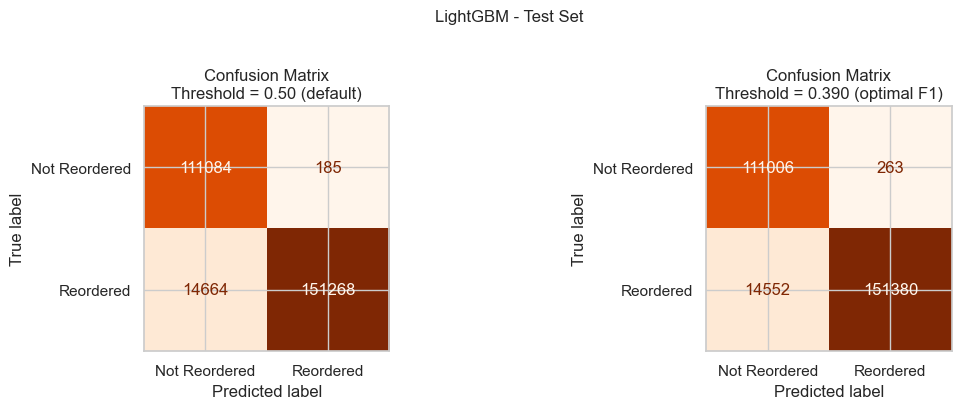

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
        axes,
        [y_pred_05, y_pred_opt],
        [f'Threshold = 0.50 (default)',
         f'Threshold = {best_threshold:.3f} (optimal F1)']):

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Reordered', 'Reordered'])
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f'Confusion Matrix\n{title}')

plt.suptitle('LightGBM - Test Set', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 7.4 Probability Distribution & Calibration

LightGBM probabilities tend to be better separated and more evenly distributed
than Logistic Regression on tabular data. The Brier Score from Section 7.1
quantifies this — a lower value indicates better-calibrated probabilities.


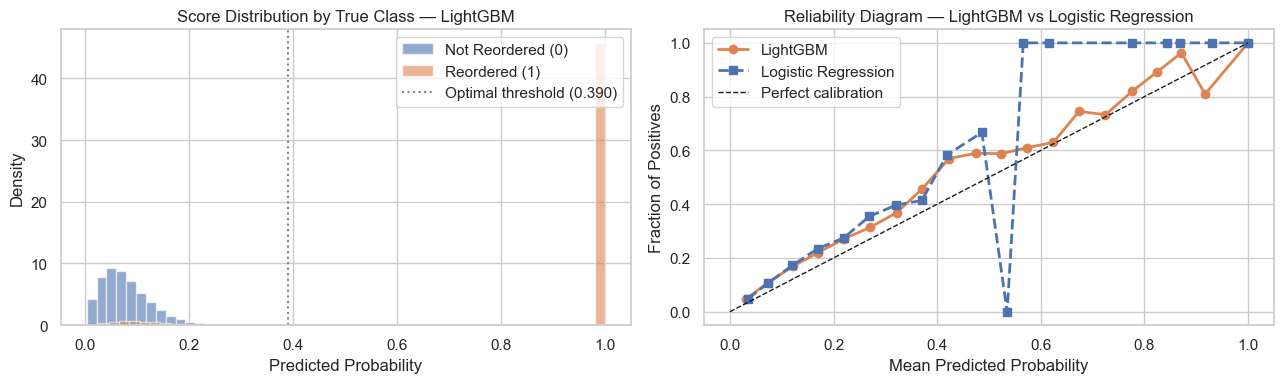

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_prob_test[y_test == 0], bins=50, alpha=0.6,
             color='#4C72B0', label='Not Reordered (0)', density=True)
axes[0].hist(y_prob_test[y_test == 1], bins=50, alpha=0.6,
             color='#DD8452', label='Reordered (1)', density=True)
axes[0].axvline(best_threshold, linestyle=':', color='grey',
                label=f'Optimal threshold ({best_threshold:.3f})')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Class — LightGBM')
axes[0].legend()

prob_true_lgb, prob_pred_lgb = calibration_curve(y_test, y_prob_test, n_bins=20)
prob_true_lr,  prob_pred_lr  = calibration_curve(y_test, y_prob_lr,   n_bins=20)

axes[1].plot(prob_pred_lgb, prob_true_lgb, 'o-', color='#DD8452', lw=2,
             label='LightGBM')
axes[1].plot(prob_pred_lr,  prob_true_lr,  's--', color='#4C72B0', lw=2,
             label='Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Reliability Diagram — LightGBM vs Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Feature Importance

LightGBM provides three built-in importance metrics:

| Metric | Meaning |
|---|---|
| `split` | Number of times a feature is used to split across all trees |
| `gain` | Total reduction in loss (impurity) from splits on this feature |

`gain` is generally more informative than `split` — a feature used rarely but
at high-gain splits is more important than one used frequently for marginal gains.
We show both for completeness.


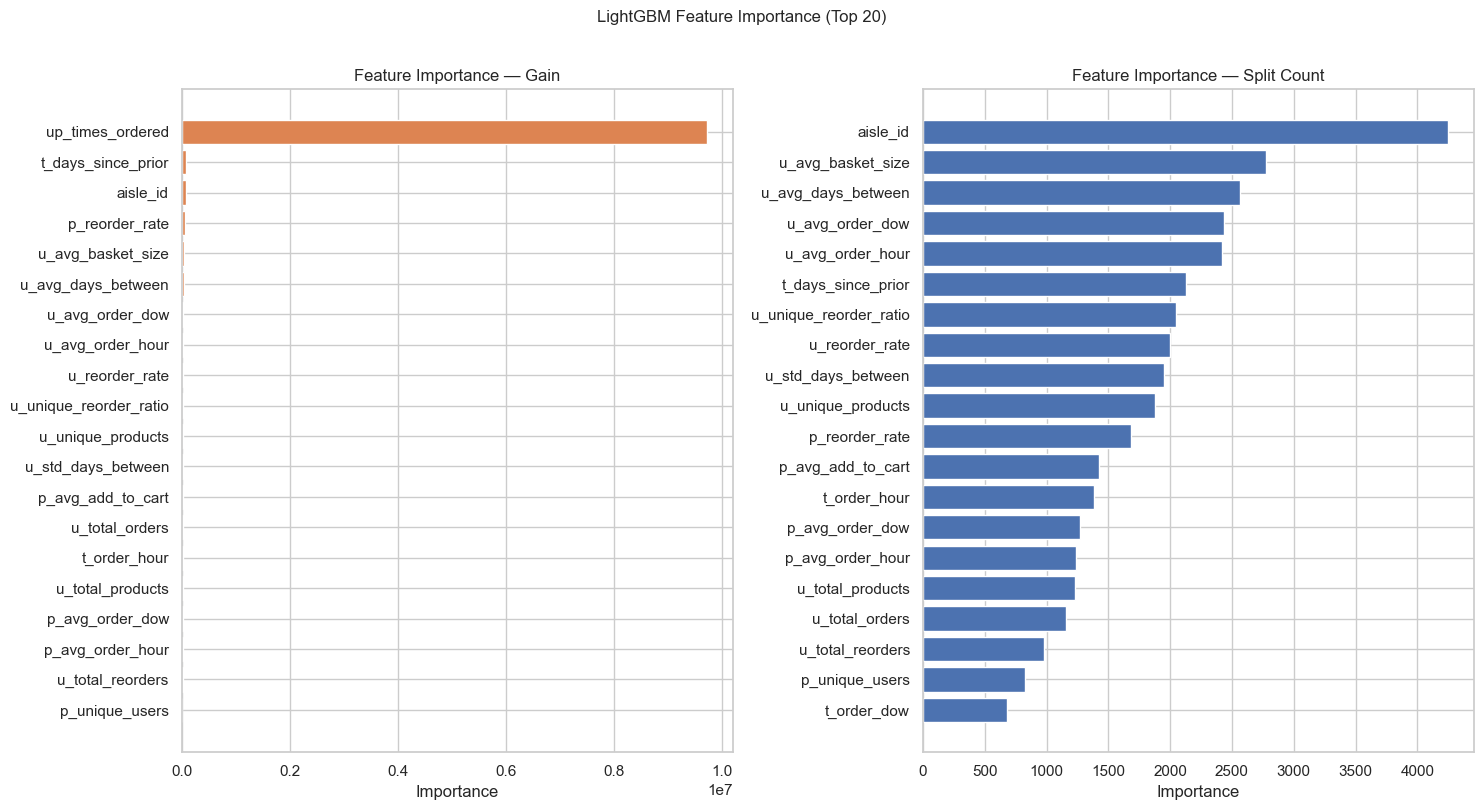

Top 10 features by gain:
               feature       importance
      up_times_ordered 9,726,640.472025
    t_days_since_prior    67,667.377190
              aisle_id    67,281.939950
        p_reorder_rate    63,561.646278
     u_avg_basket_size    33,877.742681
    u_avg_days_between    32,744.241863
       u_avg_order_dow    22,345.592684
      u_avg_order_hour    22,075.892226
        u_reorder_rate    19,940.776511
u_unique_reorder_ratio    19,926.736320


In [14]:
importance_split = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': lgb_tuned.feature_importances_,
    'type'      : 'split'
}).sort_values('importance', ascending=False)

# gain importance requires accessing the booster directly
booster = lgb_tuned.booster_
importance_gain = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': booster.feature_importance(importance_type='gain'),
    'type'      : 'gain'
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

for ax, imp_df, title, color in zip(
        axes,
        [importance_gain, importance_split],
        ['Feature Importance — Gain', 'Feature Importance — Split Count'],
        ['#DD8452', '#4C72B0']):

    top = imp_df.head(20)
    ax.barh(top['feature'], top['importance'], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.invert_yaxis()

plt.suptitle('LightGBM Feature Importance (Top 20)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("Top 10 features by gain:")
print(importance_gain[['feature', 'importance']].head(10).to_string(index=False))


## 9. Results Summary

In [15]:
results_lgb = {
    'Model'              : 'LightGBM',
    'ROC-AUC'            : round(roc_auc, 4),
    'PR-AUC (Avg Prec)'  : round(avg_prec, 4),
    'Brier Score'        : round(brier, 4),
    'Best params'        : str(grid_search.best_params_),
    'Optimal Threshold'  : round(best_threshold, 4),
    'F1 (optimal thresh)': round(f1_score(y_test, y_pred_opt), 4),
    'Precision (opt)'    : round(precision_score(y_test, y_pred_opt), 4),
    'Recall (opt)'       : round(recall_score(y_test, y_pred_opt), 4),
    'Accuracy (opt)'     : round(accuracy_score(y_test, y_pred_opt), 4),
    'F1 (0.50 thresh)'   : round(f1_score(y_test, y_pred_05), 4),
}

print("LightGBM Results")
print("-" * 50)
for k, v in results_lgb.items():
    print(f"  {k:<25} : {v}")

print("\nComparison with Logistic Regression")
print("-" * 50)
metrics = ['ROC-AUC', 'PR-AUC (Avg Prec)', 'Brier Score',
           'F1 (optimal thresh)', 'Accuracy (opt)']
for m in metrics:
    lgb_val = results_lgb[m]
    lr_val  = lr_results[m].values[0]
    if m == 'Brier Score':
        delta = lgb_val - lr_val
        better = 'LightGBM' if delta < 0 else 'Logistic Reg'
    else:
        delta = lgb_val - lr_val
        better = 'LightGBM' if delta > 0 else 'Logistic Reg'
    print(f"  {m:<25} LGB={lgb_val:.4f}  LR={float(lr_val):.4f}  "
          f"delta={delta:+.4f}  ({better} wins)")


LightGBM Results
--------------------------------------------------
  Model                     : LightGBM
  ROC-AUC                   : 0.971
  PR-AUC (Avg Prec)         : 0.9851
  Brier Score               : 0.0458
  Best params               : {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'num_leaves': 127}
  Optimal Threshold         : 0.3899
  F1 (optimal thresh)       : 0.9533
  Precision (opt)           : 0.9983
  Recall (opt)              : 0.9123
  Accuracy (opt)            : 0.9466
  F1 (0.50 thresh)          : 0.9532

Comparison with Logistic Regression
--------------------------------------------------
  ROC-AUC                   LGB=0.9710  LR=0.9689  delta=+0.0021  (LightGBM wins)
  PR-AUC (Avg Prec)         LGB=0.9851  LR=0.9841  delta=+0.0010  (LightGBM wins)
  Brier Score               LGB=0.0458  LR=0.0472  delta=-0.0014  (LightGBM wins)
  F1 (optimal thresh)       LGB=0.9533  LR=0.9520  delta=+0.0013  (LightGBM wins)
  Accuracy (opt)            LG

## 10. Save Model & Results

In [16]:
save_dir = MODEL_DIR
os.makedirs(save_dir, exist_ok=True)

joblib.dump(lgb_tuned,       os.path.join(save_dir, 'lgb_tuned.pkl'))
joblib.dump(importance_gain, os.path.join(save_dir, 'lgb_importance.pkl'))

results_df = pd.DataFrame([results_lgb])
results_df.to_csv(os.path.join(save_dir, 'lgb_results.csv'), index=False)

print(f"Saved to: {os.path.abspath(save_dir)}")
for fname in ['lgb_tuned.pkl', 'lgb_importance.pkl', 'lgb_results.csv']:
    fpath = os.path.join(save_dir, fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f"  {fname:<30} {size:>8.2f} MB")


Saved to: /Users/martinmilon/Documents/DTSC870/models
  lgb_tuned.pkl                      4.22 MB
  lgb_importance.pkl                 0.00 MB
  lgb_results.csv                    0.00 MB


## 11. Key Takeaways & Handoff to Step 6

### What to look for in these results

**ROC-AUC and PR-AUC:** LightGBM should improve on Logistic Regression's
0.9689 / 0.9841. Even a modest gain (+0.005 to +0.02) is meaningful at this
performance level given the dataset size.

**Brier Score:** LightGBM typically produces better-calibrated probabilities
on tabular data. A lower Brier Score than 0.0472 confirms this.

**Feature importance vs. Logistic Regression coefficients:** The gain importance
chart provides a clean, interpretable ranking unaffected by the separation issue
that inflated `up_avg_add_to_cart` and `up_orders_since_last` coefficients in Step 4.
If these same features appear at the top of the gain chart, it confirms they carry
genuine signal — the Step 4 issue was a numerical artefact, not a feature quality problem.

**Calibration diagram:** If LightGBM's reliability curve is closer to the diagonal
than Logistic Regression's, it confirms better probability calibration — relevant
if predicted probabilities are used for business decisions (e.g. personalised offers).

### What Step 6 will cover
- Side-by-side comparison table of all metrics
- Decision on whether to revisit the Step 4 separation issue
- Discussion of which model to recommend and why
- Next steps: threshold selection for deployment, potential improvements
